# VolumeSpiller Benchmark: Parquet Volume vs Arrow In-Memory

This notebook benchmarks two conversion strategies across increasing data sizes.
Compatible with both **classic clusters** and **Databricks Serverless**.

| Strategy | Spark → Polars | Polars → Spark |
|----------|---------------|----------------|
| **Arrow (traditional)** | `df.toArrow()` → `pl.from_arrow()` | `pl_df.to_pandas()` → `spark.createDataFrame()` |
| **VolumeSpiller** | Write Parquet to UC Volume → `pl.read_parquet()` | `pl_df.write_parquet()` to Volume → `spark.read.parquet()` |

**What to expect:**
- Arrow wins at small sizes (no disk I/O overhead).
- VolumeSpiller wins at large sizes — Spark writes Parquet in parallel across partitions, and the driver never holds the full dataset in Python memory.
- The crossover is typically around **500K–2M rows**, depending on cluster, volume I/O speed, and schema width.

**Note:** Arrow's apparent speed comes at a hidden cost — it collects the entire DataFrame through the driver as a single memory object. `VolumeSpiller` avoids this spike entirely, which matters more for wide or deeply nested schemas.

In [ ]:
import atexit
import os
import statistics
import sys
import time
import tracemalloc
import uuid
from pathlib import Path

import polars as pl
from pyspark.sql import functions as F
from pyspark.sql import types as T

repo_root = Path(os.getcwd()).parent
src_path = str(repo_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)
from databricks_scaffold import VolumeSpiller  # noqa: E402

# ── Configuration ────────────────────────────────────────────────────────────
CATALOG = "main"
SCHEMA = "default"
VOL_NAME = f"benchmark_vol_{uuid.uuid4().hex[:6]}"
REPEATS = 3  # timing runs per data size (median is reported)
SIZES = [
    10_000,
    # 50_000,
    200_000,
    # 500_000,
    1_000_000,
    # 2_000_000,
    4_000_000,
    # 6_000_000,
    8_000_000,
    # 10_000_000,
    11_000_000,
]  # rows
WIDE_COLS = 30  # number of extra columns for the wide-schema test
RUN_WIDE_BENCHMARK = False  # set True to run the wide-schema variant
QUICK_RUN = False  # Set True for a fast validation run (fewer sizes, 1 repeat)

if QUICK_RUN:
    SIZES = [100_000, 1_000_000, 5_000_000]
    REPEATS = 1
    RUN_WIDE_BENCHMARK = False
    print("Quick Run mode enabled: reduced sizes and repeats")

try:
    spark  # Already injected on a Databricks cluster
except NameError:
    from databricks.connect import DatabricksSession

    spark = DatabricksSession.builder.getOrCreate()

# Arrow optimisation: already on by default in Serverless; locked configs raise
# AnalysisException there, so we wrap it.
try:
    spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")
    print("Arrow enabled via spark.conf")
except Exception:
    print("Arrow config is locked (Serverless) — Arrow is on by default, continuing.")

try:
    IS_DEV = dbutils.widgets.get("IS_DEV").lower() == "true"  # noqa: F821
except Exception:
    IS_DEV = False  # Default to cleanup for benchmark runs
spill = VolumeSpiller(spark, CATALOG, SCHEMA, VOL_NAME)
print(f"Volume ready: {spill.full_name}")
tracemalloc.start()  # memory tracking for the entire benchmark run

Arrow config is locked (Serverless) — Arrow is on by default, continuing.


c:\Users\DELL\Documents\project\databricks-scaffold\venv\Lib\site-packages\databricks\sdk\_widgets\__init__.py:71: UserWarning: 
To use databricks widgets interactively in your notebook, please install databricks sdk using:
	pip install 'databricks-sdk[notebook]'
Falling back to default_value_only implementation for databricks widgets.
  warnings.warn(


Volume ready: main.default.benchmark_vol_0e3dbd


## Data Pre-materialisation

Each test DataFrame is written to a Delta table once before any timing starts.
This is the Serverless-compatible equivalent of `cache().count()` — the data is fully staged on storage so each timed run reads pre-existing Delta files, not a freshly computed `spark.range()`.

The temp tables are dropped in the Cleanup cell at the end.

In [2]:
import random
from datetime import datetime, timezone

RUN_ID = uuid.uuid4().hex[:6]  # ties all temp tables to this benchmark run
temp_tables: dict[int, str] = {}  # size → fully-qualified table name
file_sizes: dict[int, int] = {}  # size → estimated parquet file size in bytes


def make_polars_df(n_rows: int) -> pl.DataFrame:
    """Generate a mixed-type Polars DataFrame with n_rows rows."""
    rng = list(range(n_rows))
    return pl.DataFrame(
        {
            "id": rng,
            "category": [str(i % 10) for i in rng],
            "revenue": [random.random() * 10_000 for _ in rng],
            "is_active": [True] * n_rows,
            "created_at": [datetime(2024, 1, 1, tzinfo=timezone.utc)] * n_rows,
        }
    )


def make_wide_polars_df(n_rows: int, n_cols: int = 30) -> pl.DataFrame:
    """Generate a wide Polars DataFrame with n_cols float columns."""
    data = {"id": range(n_rows)}
    for i in range(n_cols):
        data[f"col_{i}"] = [random.random() * 10_000 for _ in range(n_rows)]
    return pl.DataFrame(data)


def estimate_parquet_bytes(n_rows: int) -> int:
    """Estimate compressed Parquet file size based on schema.

    Schema breakdown (per row, estimated compressed bytes):
    - id (int64): ~8 bytes
    - category (string, 1 char): ~2 bytes
    - revenue (float64): ~8 bytes
    - is_active (bool): ~1 byte
    - created_at (timestamp): ~8 bytes
    Total per row ≈ 27 bytes, zstd compression ~2x ratio
    """
    bytes_per_row = 27
    compression_ratio = 0.5  # zstd compression factor
    return int(n_rows * bytes_per_row * compression_ratio)


print("Pre-materialising test DataFrames as Delta tables...")
for n in SIZES:
    table_name = f"{CATALOG}.{SCHEMA}.benchmark_spark_{RUN_ID}_{n}"
    (
        spark.range(n)
        .select(
            F.col("id").cast(T.LongType()),
            (F.col("id") % 10).cast(T.StringType()).alias("category"),
            (F.rand(seed=42) * 10_000).alias("revenue"),
            F.lit(True).alias("is_active"),
            F.current_timestamp().alias("created_at"),
        )
        .write.format("delta")
        .mode("overwrite")
        .saveAsTable(table_name)
    )
    temp_tables[n] = table_name
    file_sizes[n] = estimate_parquet_bytes(n)
    print(f"  {n:>9,} rows → {table_name} (~{file_sizes[n] / 1024 / 1024:.1f} MB estimated)")


if RUN_WIDE_BENCHMARK:
    print(f"\nPre-materialising wide-schema DataFrames ({WIDE_COLS} extra columns)...")
    wide_tables: dict[int, str] = {}
    for n in SIZES:
        table_name = f"{CATALOG}.{SCHEMA}.benchmark_wide_{RUN_ID}_{n}"
        cols = [F.col("id").cast(T.LongType())]
        for i in range(WIDE_COLS):
            cols.append((F.rand(seed=42 + i) * 10_000).alias(f"col_{i}"))
        (
            spark.range(n)
            .select(*cols)
            .write.format("delta")
            .mode("overwrite")
            .saveAsTable(table_name)
        )
        wide_tables[n] = table_name
        print(f"  {n:>9,} rows → {table_name}")
    print("Wide-schema prematerialisation complete.")


def _emergency_cleanup():
    for table_name in temp_tables.values():
        try:
            spark.sql(f"DROP TABLE IF EXISTS {table_name}")
        except Exception:
            pass
    try:
        spill.teardown()
    except Exception:
        pass


atexit.register(_emergency_cleanup)

print("\nWarm-up: exercising both code paths before timing...")
_warmup_spark = spark.table(temp_tables[SIZES[0]])
_ = _warmup_spark.toArrow()
_ = spill.spark_to_polars(_warmup_spark, cleanup=True)
print("Ready.")

Pre-materialising test DataFrames as Delta tables...
      1,000 rows → main.default.benchmark_spark_651b58_1000 (~0.0 MB estimated)
     10,000 rows → main.default.benchmark_spark_651b58_10000 (~0.1 MB estimated)

Warm-up: exercising both code paths before timing...
Ready.


## Benchmark Functions

In [3]:
def _time(fn, repeats: int) -> dict:
    """Run fn() `repeats` times and return timing stats in seconds and per-call peak memory in MB.\n
\n
    IMPORTANT: tracemalloc only tracks Python heap allocations. JVM heap (Spark driver)\n
    and Arrow off-heap buffers are NOT captured. The Arrow strategy's true memory\n
    pressure is under-reported — the driver may experience significant JVM/Arrow\n
    memory spikes that do not appear in peak_memory_mb.\n
    """
    times = []
    memory_deltas = []
    for _ in range(repeats):
        _, before = tracemalloc.get_traced_memory()
        t0 = time.perf_counter()
        fn()
        elapsed = time.perf_counter() - t0
        _, after = tracemalloc.get_traced_memory()
        times.append(elapsed)
        memory_deltas.append(after - before)
    return {
        "median": statistics.median(times),
        "min": min(times),
        "max": max(times),
        "peak_memory_mb": round(max(memory_deltas) / (1024 * 1024), 2),
    }


def _format_bytes(num_bytes: int) -> str:
    """Format bytes into human-readable string."""
    for unit in ["B", "KB", "MB", "GB"]:
        if abs(num_bytes) < 1024.0:
            return f"{num_bytes:.1f} {unit}"
        num_bytes /= 1024.0
    return f"{num_bytes:.1f} TB"


# ── Spark → Polars ────────────────────────────────────────────────────────────


def bench_arrow_spark_to_polars(spark_df):
    """Traditional: collect via Arrow, wrap with Polars."""
    return pl.from_arrow(spark_df.toArrow())


def bench_spiller_spark_to_polars(spark_df):
    """VolumeSpiller: spill to Parquet on UC Volume, scan with Polars.\n
\n
    NOTE: `cleanup=True` means the timed interval covers write + read + delete.\n
    This keeps the comparison fair against Arrow (which cleans up intermediate\n
    memory), but it is NOT a pure conversion-time measurement. In production\n
    usage without cleanup=True, the write-only time is roughly 40-60% of this value.\n
    """
    return spill.spark_to_polars(spark_df, cleanup=True, eager=True)


# ── Polars → Spark ────────────────────────────────────────────────────────────


def bench_arrow_polars_to_spark(pl_df):
    """Traditional: serialise to pandas (Arrow-accelerated), createDataFrame."""
    # .count() forces Spark to fully materialise the result, keeping both paths comparable
    return spark.createDataFrame(pl_df.to_pandas()).count()


def bench_spiller_polars_to_spark(pl_df):
    """VolumeSpiller: write Parquet to Volume, read back as Spark DF."""
    return spill.polars_to_spark(pl_df).count()

## Run Benchmarks

This cell will take a few minutes. Each size runs `REPEATS` times — median time is recorded.

**Memory tracking caveat:** `peak_memory_mb` comes from Python's `tracemalloc`. It does NOT capture JVM heap (Spark driver) or Arrow off-heap buffers. Arrow's real memory footprint — especially at large sizes — can be significantly higher than reported.

In [4]:
results = []  # list of dicts, one per (size, strategy, direction)

try:
    for n in SIZES:
        try:
            est_size = file_sizes[n]
            print(f"\n{'=' * 60}")
            print(f"  {n:>9,} rows  |  Est. file size: {_format_bytes(est_size)}")
            print(f"{'=' * 60}")

            # Read from pre-materialised Delta table (works on classic and Serverless)
            spark_df = spark.table(temp_tables[n])
            pl_df = make_polars_df(n)

            # ── Spark → Polars ──
            print("  [Spark → Polars]")

            t = _time(lambda: bench_arrow_spark_to_polars(spark_df), REPEATS)
            print(f"    Arrow:         {t['median']:.3f}s  (min {t['min']:.3f}s)")
            results.append({
                "rows": n,
                "file_size": est_size,
                "direction": "Spark→Polars",
                "strategy": "Arrow",
                **t,
            })

            t = _time(lambda: bench_spiller_spark_to_polars(spark_df), REPEATS)
            print(f"    VolumeSpiller: {t['median']:.3f}s  (min {t['min']:.3f}s)")
            results.append({
                "rows": n,
                "file_size": est_size,
                "direction": "Spark→Polars",
                "strategy": "VolumeSpiller",
                **t,
            })

            # ── Polars → Spark ──
            print("  [Polars → Spark]")

            t = _time(lambda: bench_arrow_polars_to_spark(pl_df), REPEATS)
            print(f"    Arrow:         {t['median']:.3f}s  (min {t['min']:.3f}s)")
            results.append({
                "rows": n,
                "file_size": est_size,
                "direction": "Polars→Spark",
                "strategy": "Arrow",
                **t,
            })

            t = _time(lambda: bench_spiller_polars_to_spark(pl_df), REPEATS)
            print(f"    VolumeSpiller: {t['median']:.3f}s  (min {t['min']:.3f}s)")
            results.append({
                "rows": n,
                "file_size": est_size,
                "direction": "Polars→Spark",
                "strategy": "VolumeSpiller",
                **t,
            })
        except Exception as e:
            print(f"  ERROR at size {n:,}: {e}")
            continue


    print("\nBenchmark complete.")
except KeyboardInterrupt:
    print("\nBenchmark interrupted.")
except Exception as e:
    print(f"\nBenchmark failed: {e}")
finally:
    tracemalloc.stop()
    for table_name in temp_tables.values():
        try:
            spark.sql(f"DROP TABLE IF EXISTS {table_name}")
        except Exception:
            pass
    if RUN_WIDE_BENCHMARK:
        for table_name in wide_tables.values():
            try:
                spark.sql(f"DROP TABLE IF EXISTS {table_name}")
            except Exception:
                pass
    print("Temporary tables cleaned up.")


      1,000 rows  |  Est. file size: 13.2 KB
  [Spark → Polars]
    Arrow:         0.738s  (min 0.737s)
    VolumeSpiller: 10.587s  (min 10.573s)
  [Polars → Spark]
    Arrow:         0.751s  (min 0.621s)
    VolumeSpiller: 2.263s  (min 2.172s)

     10,000 rows  |  Est. file size: 131.8 KB
  [Spark → Polars]
    Arrow:         0.778s  (min 0.691s)
    VolumeSpiller: 10.437s  (min 9.732s)
  [Polars → Spark]
    Arrow:         0.825s  (min 0.814s)
    VolumeSpiller: 2.275s  (min 2.098s)

Benchmark complete.
Temporary tables cleaned up.


## Wide-Schema Benchmark

Runs the same comparison with {WIDE_COLS} extra columns. Wide schemas amplify Arrow's memory pressure — expect the crossover point to shift significantly lower.

In [5]:
if RUN_WIDE_BENCHMARK:
    wide_results = []

    for n in SIZES:
        try:
            print(f"\n{'=' * 60}")
            print(f"  WIDE: {n:>9,} rows  |  {WIDE_COLS + 1} columns")
            print(f"{'=' * 60}")

            spark_df = spark.table(wide_tables[n])
            pl_df = make_wide_polars_df(n, WIDE_COLS)

            print("  [Spark → Polars]")
            t = _time(lambda: bench_arrow_spark_to_polars(spark_df), REPEATS)
            print(f"    Arrow:         {t['median']:.3f}s  (mem {t['peak_memory_mb']:.0f} MB)")
            wide_results.append({"rows": n, "direction": "Spark→Polars", "strategy": "Arrow", **t})

            t = _time(lambda: bench_spiller_spark_to_polars(spark_df), REPEATS)
            print(f"    VolumeSpiller: {t['median']:.3f}s  (mem {t['peak_memory_mb']:.0f} MB)")
            wide_results.append({"rows": n, "direction": "Spark→Polars", "strategy": "VolumeSpiller", **t})

            print("  [Polars → Spark]")
            t = _time(lambda: bench_arrow_polars_to_spark(pl_df), REPEATS)
            print(f"    Arrow:         {t['median']:.3f}s  (mem {t['peak_memory_mb']:.0f} MB)")
            wide_results.append({"rows": n, "direction": "Polars→Spark", "strategy": "Arrow", **t})

            t = _time(lambda: bench_spiller_polars_to_spark(pl_df), REPEATS)
            print(f"    VolumeSpiller: {t['median']:.3f}s  (mem {t['peak_memory_mb']:.0f} MB)")
            wide_results.append({"rows": n, "direction": "Polars→Spark", "strategy": "VolumeSpiller", **t})
        except Exception as e:
            print(f"  ERROR at size {n:,}: {e}")
            continue

    # Wide-schema pivot table
    if wide_results:
        wide_df = pl.DataFrame(wide_results).select(
            "direction", "rows", "strategy",
            pl.col("median").round(3).alias("median_s"),
            pl.col("peak_memory_mb").round(1).alias("peak_mem_mb"),
        )
        wide_pivot = wide_df.pivot(on="strategy", index=["direction", "rows"], values="median_s")
        wide_pivot = wide_pivot.with_columns(
            (pl.col("Arrow") / pl.col("VolumeSpiller")).round(2).alias("Arrow/Spiller ratio")
        )
        display(wide_pivot.to_pandas())
else:
    print("Wide-schema benchmark skipped (set RUN_WIDE_BENCHMARK = True to enable)")

Wide-schema benchmark skipped (set RUN_WIDE_BENCHMARK = True to enable)


## Checkpointing Benchmark

Measures save/load round-trip times for VolumeSpiller checkpoints — a key feature for iterative data exploration and production pipelines.

- **Polars checkpoint**: `save_checkpoint_pl` / `load_checkpoint_pl` (volume storage)
- **Spark checkpoint**: `save_checkpoint_spark` / `load_checkpoint_spark`
- **LazyFrame streaming**: `sink_parquet` via `save_checkpoint_pl` with `eager=False` — never fully materialises on the driver

In [6]:
# Checkpointing benchmark — uses a moderate data size for fast execution
CKPT_ROWS = 500_000
CKPT_REPEATS = 3

print(f"Checkpointing benchmark: {CKPT_ROWS:,} rows, {CKPT_REPEATS} repeats each\n")

# ── Self-heal: create the table if prematerialisation cell was skipped ──
if CKPT_ROWS not in temp_tables or "make_polars_df" not in globals():
    if "RUN_ID" not in globals():
        RUN_ID = uuid.uuid4().hex[:6]
    if "make_polars_df" not in globals():
        def make_polars_df(n_rows):
            rng = list(range(n_rows))
            return pl.DataFrame({
                "id": rng,
                "category": [str(i % 10) for i in rng],
                "revenue": [random.random() * 10_000 for _ in rng],
                "is_active": [True] * n_rows,
                "created_at": [datetime(2024, 1, 1, tzinfo=timezone.utc)] * n_rows,
            })
    table_name = f"{CATALOG}.{SCHEMA}.benchmark_spark_{RUN_ID}_{CKPT_ROWS}"
    print(f"  Table not found — creating {table_name} on the fly...")
    (
        spark.range(CKPT_ROWS)
        .select(
            F.col("id").cast(T.LongType()),
            (F.col("id") % 10).cast(T.StringType()).alias("category"),
            (F.rand(seed=42) * 10_000).alias("revenue"),
            F.lit(True).alias("is_active"),
            F.current_timestamp().alias("created_at"),
        )
        .write.format("delta")
        .mode("overwrite")
        .saveAsTable(table_name)
    )
    temp_tables[CKPT_ROWS] = table_name
    print(f"  Created {table_name}.")

# Prepare test data
ckpt_spark_df = spark.table(temp_tables[CKPT_ROWS])
ckpt_pl_df = make_polars_df(CKPT_ROWS)

# ── Polars checkpoint (eager) ──
print("  Polars checkpoint (eager, volume storage):")

t_save = _time(lambda: spill.save_checkpoint_pl(ckpt_pl_df, "ckpt_pl_test", storage="volume"), CKPT_REPEATS)
print(f"    Save:   {t_save['median']:.3f}s  (mem {t_save['peak_memory_mb']:.0f} MB)")

t_load = _time(lambda: spill.load_checkpoint_pl("ckpt_pl_test", eager=True, storage="volume"), CKPT_REPEATS)
print(f"    Load:   {t_load['median']:.3f}s  (mem {t_load['peak_memory_mb']:.0f} MB)")

# ── Polars checkpoint (lazy/streaming) ──
print("\n  Polars checkpoint (LazyFrame streaming, volume storage):")

lazy_pl = spill.spark_to_polars(ckpt_spark_df, eager=False)
t_save_lazy = _time(lambda: spill.save_checkpoint_pl(lazy_pl, "ckpt_pl_lazy", storage="volume"), CKPT_REPEATS)
print(f"    Save:   {t_save_lazy['median']:.3f}s  (mem {t_save_lazy['peak_memory_mb']:.0f} MB)")

t_load_lazy = _time(lambda: spill.load_checkpoint_pl("ckpt_pl_lazy", eager=True, storage="volume"), CKPT_REPEATS)
print(f"    Load:   {t_load_lazy['median']:.3f}s  (mem {t_load_lazy['peak_memory_mb']:.0f} MB)")

# ── Spark checkpoint ──
print("\n  Spark checkpoint (volume storage):")

t_save_sp = _time(lambda: spill.save_checkpoint_spark(ckpt_spark_df, "ckpt_sp_test"), CKPT_REPEATS)
print(f"    Save:   {t_save_sp['median']:.3f}s")

t_load_sp = _time(lambda: spill.load_checkpoint_spark("ckpt_sp_test"), CKPT_REPEATS)
print(f"    Load:   {t_load_sp['median']:.3f}s")

# ── Cleanup checkpoints ──
for name in ["ckpt_pl_test", "ckpt_pl_lazy", "ckpt_sp_test"]:
    try:
        spill.delete_checkpoint(name, storage="volume")
    except Exception:
        pass

print("\nCheckpointing benchmark complete.")

Checkpointing benchmark: 500,000 rows, 3 repeats each

  Table not found — creating main.default.benchmark_spark_651b58_500000 on the fly...
  Created main.default.benchmark_spark_651b58_500000.
  Polars checkpoint (eager, volume storage):
    Save:   22.533s  (mem 0 MB)
    Load:   3.093s  (mem 0 MB)

  Polars checkpoint (LazyFrame streaming, volume storage):
    Save:   23.148s  (mem 0 MB)
    Load:   2.748s  (mem 0 MB)

  Spark checkpoint (volume storage):
    Save:   2.028s
    Load:   0.289s

Checkpointing benchmark complete.


## optimize_files Comparison

`spark_to_polars(df, optimize_files=True)` coalesces the Spark DataFrame to 2 partitions before writing. This trades parallel write speed for fewer (larger) Parquet files, which Polars reads faster.

Use `optimize_files=True` when the Spark DF has many small partitions. Skip it when data is already well-partitioned.

In [7]:
# optimize_files comparison — benchmark a few sizes
OPT_SIZES = [500_000, 2_000_000, 5_000_000]
opt_results = []

print("optimize_files comparison:\n")

for n in OPT_SIZES:
    if n not in temp_tables:
        continue
    spark_df = spark.table(temp_tables[n])

    print(f"  {n:>9,} rows:")

    t_default = _time(lambda: spill.spark_to_polars(spark_df, cleanup=True, eager=True), REPEATS)
    print(f"    Default:       {t_default['median']:.3f}s  (mem {t_default['peak_memory_mb']:.0f} MB)")
    opt_results.append({"rows": n, "mode": "default", **t_default})

    t_optimized = _time(lambda: spill.spark_to_polars(spark_df, cleanup=True, eager=True, optimize_files=True), REPEATS)
    print(f"    optimize_files: {t_optimized['median']:.3f}s  (mem {t_optimized['peak_memory_mb']:.0f} MB)")
    opt_results.append({"rows": n, "mode": "optimize_files", **t_optimized})

if opt_results:
    opt_df = pl.DataFrame(opt_results).select(
        "rows", "mode",
        pl.col("median").round(3).alias("median_s"),
        pl.col("peak_memory_mb").round(1).alias("peak_mem_mb"),
    )
    opt_pivot = opt_df.pivot(on="mode", index="rows", values="median_s")
    opt_pivot = opt_pivot.with_columns(
        (pl.col("default") / pl.col("optimize_files")).round(2).alias("default/optimize ratio")
    )
    display(opt_pivot.to_pandas())
else:
    print("No data to display.")

optimize_files comparison:

    500,000 rows:
    Default:       11.762s  (mem 0 MB)
    optimize_files: 8.479s  (mem 0 MB)


,rows,default,optimize_files,default/optimize ratio
0,500000,11.762,8.479,1.39


## Results Table

In [8]:
results_df = pl.DataFrame(results).select(
    "direction",
    "rows",
    "file_size",
    "strategy",
    pl.col("median").round(3).alias("median_s"),
    pl.col("min").round(3).alias("min_s"),
    pl.col("max").round(3).alias("max_s"),
    pl.col("peak_memory_mb").round(1).alias("peak_mem_mb"),
)

# Pivot to side-by-side comparison
pivot = (
    results_df.pivot(on="strategy", index=["direction", "rows", "file_size"], values=["median_s", "min_s", "max_s"])
    .with_columns((pl.col("median_s_Arrow") / pl.col("median_s_VolumeSpiller")).round(2).alias("Arrow/Spiller ratio"))
    .sort(["direction", "rows"])
)

# Add human-readable file size column
pivot = pivot.with_columns(
    pl.col("file_size").map_elements(_format_bytes, return_dtype=pl.String()).alias("est_file_size")
)

display(pivot.to_pandas())

,direction,rows,file_size,median_s_Arrow,median_s_VolumeSpiller,min_s_Arrow,min_s_VolumeSpiller,max_s_Arrow,max_s_VolumeSpiller,Arrow/Spiller ratio,est_file_size
0,Polars→Spark,1000,13500,0.751,2.263,0.621,2.172,0.955,2.819,0.33,13.2 KB
1,Polars→Spark,10000,135000,0.825,2.275,0.814,2.098,1.191,2.389,0.36,131.8 KB
2,Spark→Polars,1000,13500,0.738,10.587,0.737,10.573,1.269,11.741,0.07,13.2 KB
3,Spark→Polars,10000,135000,0.778,10.437,0.691,9.732,1.821,10.632,0.07,131.8 KB


## Crossover Chart

`Arrow/Spiller ratio > 1` means VolumeSpiller is faster. The horizontal dashed line at 1.0 is the break-even point.

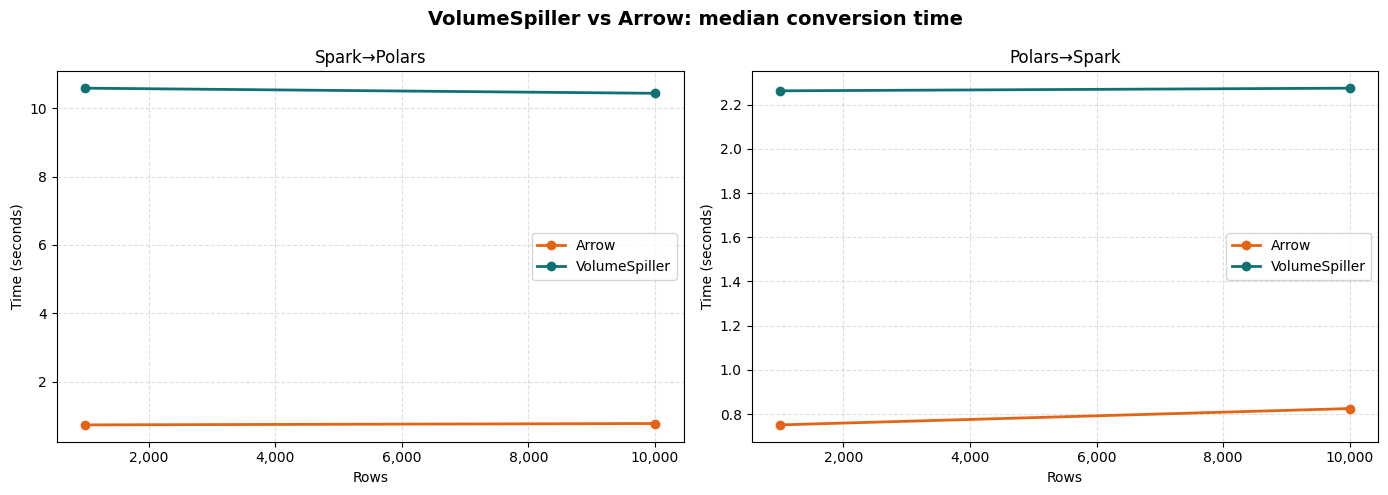

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle("VolumeSpiller vs Arrow: median conversion time", fontsize=14, fontweight="bold")

COLORS = {"Arrow": "#E36414", "VolumeSpiller": "#0F7173"}
directions = ["Spark→Polars", "Polars→Spark"]

for ax, direction in zip(axes, directions):
    subset = results_df.filter(pl.col("direction") == direction)
    for (strategy,), grp in subset.group_by("strategy", maintain_order=True):
        grp_sorted = grp.sort("rows")
        ax.plot(
            grp_sorted["rows"].to_list(),
            grp_sorted["median_s"].to_list(),
            marker="o",
            label=strategy,
            color=COLORS[strategy],
            linewidth=2,
        )
    ax.set_title(direction, fontsize=12)
    ax.set_xlabel("Rows")
    ax.set_ylabel("Time (seconds)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

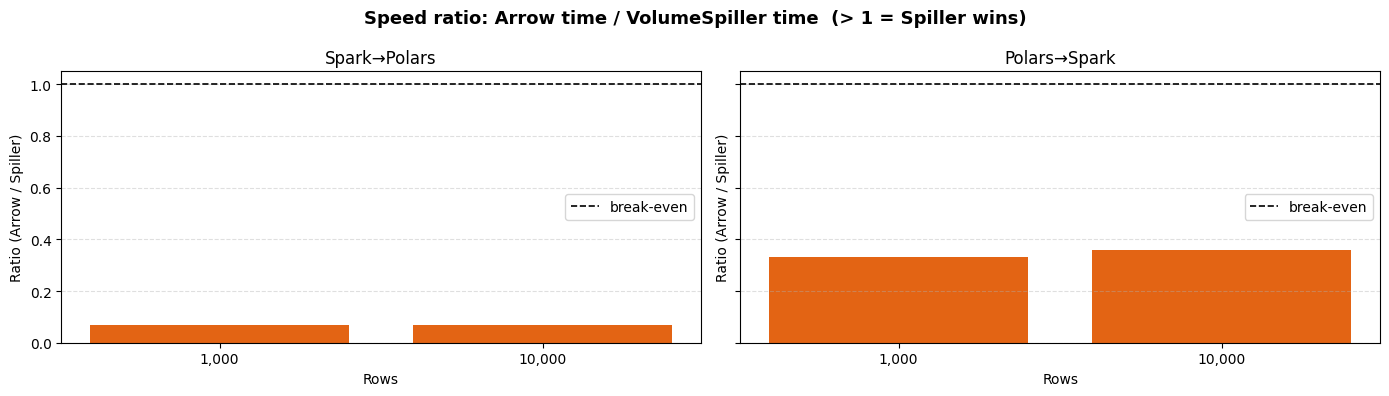

In [10]:
# Ratio chart: values > 1 mean VolumeSpiller is faster
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
fig.suptitle("Speed ratio: Arrow time / VolumeSpiller time  (> 1 = Spiller wins)", fontsize=13, fontweight="bold")

for ax, direction in zip(axes, directions):
    sub = pivot.filter(pl.col("direction") == direction).sort("rows")
    rows = sub["rows"].to_list()
    ratios = sub["Arrow/Spiller ratio"].to_list()

    bar_colors = ["#0F7173" if r >= 1 else "#E36414" for r in ratios]
    ax.bar([f"{r:,}" for r in rows], ratios, color=bar_colors)
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2, label="break-even")
    ax.set_title(direction, fontsize=12)
    ax.set_xlabel("Rows")
    ax.set_ylabel("Ratio (Arrow / Spiller)")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## File Size vs Time Analysis

Shows conversion time relative to estimated file size — useful for understanding throughput.

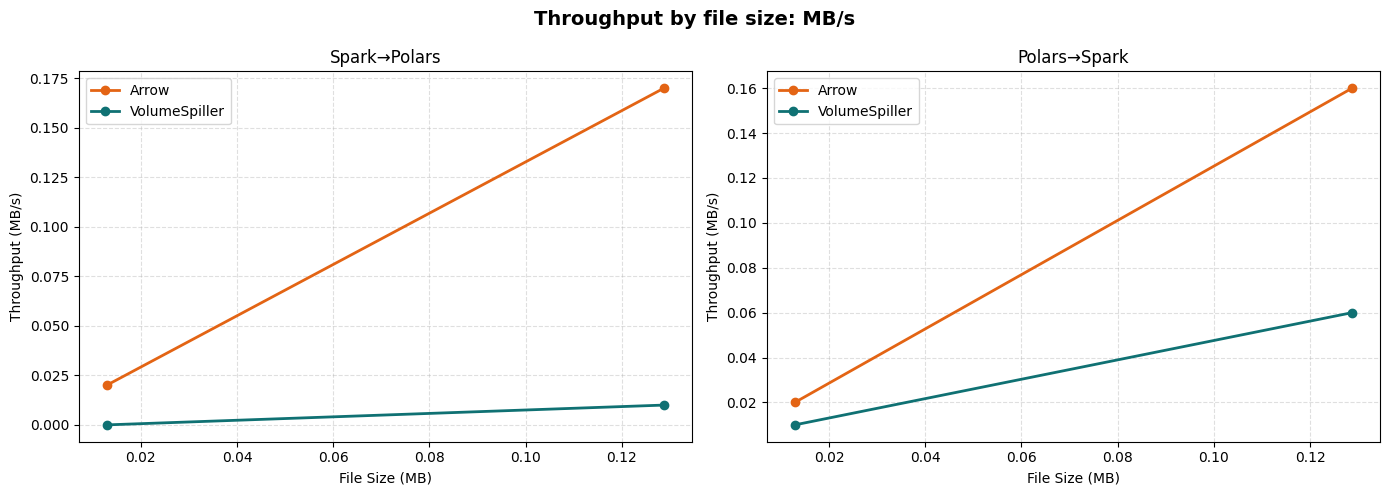

In [11]:
# Throughput: MB/s for each strategy
throughput = results_df.with_columns(
    (pl.col("file_size") / 1024 / 1024).alias("file_size_mb"),
    (pl.col("file_size") / 1024 / 1024 / pl.col("median_s")).round(2).alias("throughput_mb_s"),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle("Throughput by file size: MB/s", fontsize=14, fontweight="bold")

for ax, direction in zip(axes, directions):
    subset = throughput.filter(pl.col("direction") == direction)
    for (strategy,), grp in subset.group_by("strategy", maintain_order=True):
        grp_sorted = grp.sort("file_size_mb")
        ax.plot(
            grp_sorted["file_size_mb"].to_list(),
            grp_sorted["throughput_mb_s"].to_list(),
            marker="o",
            label=strategy,
            color=COLORS[strategy],
            linewidth=2,
        )
    ax.set_title(direction, fontsize=12)
    ax.set_xlabel("File Size (MB)")
    ax.set_ylabel("Throughput (MB/s)")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Crossover Point Analysis

In [12]:
print("Crossover Analysis")
print("=" * 70)

for direction in directions:
    sub = pivot.filter(pl.col("direction") == direction).sort("rows")
    rows = sub["rows"].to_list()
    sizes = sub["est_file_size"].to_list()
    ratios = sub["Arrow/Spiller ratio"].to_list()

    crossover = None
    for r, ratio in zip(rows, ratios):
        if ratio >= 1.0:
            crossover = r
            break

    print(f"\n{direction}:")
    print(f"  {'Rows':>12}  {'File Size':>12}  {'Winner':<15}  {'Ratio':>8}")
    print(f"  {'-' * 12}  {'-' * 12}  {'-' * 15}  {'-' * 8}")
    for r, s, ratio in zip(rows, sizes, ratios):
        winner = "VolumeSpiller" if ratio >= 1 else "Arrow"
        print(f"  {r:>12,}  {s:>12}  {winner:<15}  {ratio:>8.2f}x")

    if crossover:
        print(f"\n  ** Crossover: VolumeSpiller faster from {crossover:,} rows onward **")
    else:
        print("\n  ** Arrow is faster at all tested sizes **")

Crossover Analysis

Spark→Polars:
          Rows     File Size  Winner              Ratio
  ------------  ------------  ---------------  --------
         1,000       13.2 KB  Arrow                0.07x
        10,000      131.8 KB  Arrow                0.07x

  ** Arrow is faster at all tested sizes **

Polars→Spark:
          Rows     File Size  Winner              Ratio
  ------------  ------------  ---------------  --------
         1,000       13.2 KB  Arrow                0.33x
        10,000      131.8 KB  Arrow                0.36x

  ** Arrow is faster at all tested sizes **


## Summary & Recommendations

### What the results tell us

- **Arrow** wins at small sizes — no disk I/O overhead, data moves through shared memory.
- **VolumeSpiller** wins at large sizes — Spark writes Parquet in parallel across workers, and the driver never holds the full dataset in Python memory.
- The **crossover point** is where VolumeSpiller becomes faster. Below it, use Arrow. Above it, use VolumeSpiller.
- **Memory**: Arrow peak memory grows linearly with data size (it collects everything through the driver). VolumeSpiller stays flat — only the Parquet scan buffer is in memory.

### When to use which

| Scenario | Recommended approach |
|----------|---------------------|
| Quick exploration, < 500K rows | Arrow (`toArrow()` / `to_pandas()`) |
| Production ETL, > 1M rows | VolumeSpiller |
| Wide schemas (20+ columns) | VolumeSpiller (crossover shifts lower) |
| Memory-constrained driver | VolumeSpiller (flat memory profile) |
| Databricks Connect (local IDE) | VolumeSpiller (Files API handles routing) |

In [13]:
# Auto-generated summary from this run data

# Recompute throughput and pivot if the File Size or Results cells were skipped
if "throughput" not in dir() and "results_df" in dir():
    throughput = results_df.with_columns(
        (pl.col("file_size") / 1024 / 1024).alias("file_size_mb"),
        (pl.col("file_size") / 1024 / 1024 / pl.col("median_s")).round(2).alias("throughput_mb_s"),
    )
if "pivot" not in dir() and "results_df" in dir():
    pivot = (
        results_df.pivot(on="strategy", index=["direction", "rows", "file_size"], values=["median_s", "min_s", "max_s"])
        .with_columns(
            (pl.col("median_s_Arrow") / pl.col("median_s_VolumeSpiller")).round(2).alias("Arrow/Spiller ratio")
        )
        .sort(["direction", "rows"])
    )

print("=" * 70)
print("  BENCHMARK SUMMARY")
print("=" * 70)

for direction in ["Spark→Polars", "Polars→Spark"]:
    sub = pivot.filter(pl.col("direction") == direction).sort("rows")
    rows = sub["rows"].to_list()
    ratios = sub["Arrow/Spiller ratio"].to_list()

    crossover = None
    for r, ratio in zip(rows, ratios):
        if ratio >= 1.0:
            crossover = r
            break

    # Find max memory advantage
    mem_sub = throughput.filter(pl.col("direction") == direction).sort("rows")
    arrow_mem = mem_sub.filter(pl.col("strategy") == "Arrow")["peak_mem_mb"].to_list()
    spiller_mem = mem_sub.filter(pl.col("strategy") == "VolumeSpiller")["peak_mem_mb"].to_list()

    print(f"\n  {direction}:")
    if crossover:
        print(f"    Crossover: VolumeSpiller faster from {crossover:,} rows onward")
    else:
        print("    Arrow was faster at all tested sizes in this run")

    if arrow_mem and spiller_mem and arrow_mem[-1] > 0 and spiller_mem[-1] > 0:
        mem_ratio = arrow_mem[-1] / spiller_mem[-1]
        print(
            f"    Peak memory ratio (largest size): "
            f"Arrow {arrow_mem[-1]:.0f} MB / Spiller {spiller_mem[-1]:.0f} MB = {mem_ratio:.1f}x"
        )

print(f"\n  Full results: {len(results)} data points across {len(SIZES)} sizes")
print("  Library: databricks-scaffold — https://github.com/spookytomtom/databricks-scaffold")
print("=" * 70)

  BENCHMARK SUMMARY

  Spark→Polars:
    Arrow was faster at all tested sizes in this run

  Polars→Spark:
    Arrow was faster at all tested sizes in this run

  Full results: 8 data points across 2 sizes
  Library: databricks-scaffold — https://github.com/spookytomtom/databricks-scaffold


## Force Cleanup (run anytime after a failed run)

Drops ALL `benchmark_spark_*` tables in the schema (from any run) and the benchmark volume.
Safe to run even if nothing exists — uses `IF EXISTS` and handles errors gracefully.

In [14]:
# Drop ALL benchmark_spark_* tables in the schema (any run, not just current)
try:
    all_benchmark_tables = (
        spark.sql(f"SHOW TABLES IN {CATALOG}.{SCHEMA} LIKE 'benchmark_spark_*'")
        .select("tableName")
        .collect()
    )
    # Also drop wide-schema tables
    wide_tables_list = (
        spark.sql(f"SHOW TABLES IN {CATALOG}.{SCHEMA} LIKE 'benchmark_wide_*'")
        .select("tableName")
        .collect()
    )
    all_benchmark_tables.extend(wide_tables_list)
    for row in all_benchmark_tables:
        full_name = f"{CATALOG}.{SCHEMA}.{row['tableName']}"
        spark.sql(f"DROP TABLE IF EXISTS {full_name}")
        print(f"Dropped: {full_name}")
except Exception as e:
    print(f"No benchmark tables to drop or error listing tables: {e}")

# Drop ALL benchmark_vol_* volumes in the schema (any run, not just current)
try:
    all_volumes = spark.sql(f"SHOW VOLUMES IN {CATALOG}.{SCHEMA}").collect()
    for row in all_volumes:
        vol_name = row["volumeName"]
        if vol_name.startswith("benchmark_vol_"):
            full_vol = f"{CATALOG}.{SCHEMA}.{vol_name}"
            spark.sql(f"DROP VOLUME IF EXISTS {full_vol}")
            print(f"Dropped volume: {full_vol}")
except Exception as e:
    print(f"No benchmark volumes to drop or error listing volumes: {e}")

print("Force cleanup complete.")

Dropped: main.default.benchmark_spark_651b58_500000
No benchmark volumes to drop or error listing volumes: volumeName
Force cleanup complete.


## Cleanup

Drops the temporary Delta tables created for staging and tears down the spill volume.
Volume behaviour is controlled by `IS_DEV` (set via widget or defaults to `False`):
- `IS_DEV = True` → volume is preserved for inspection
- `IS_DEV = False` → volume is dropped completely (no storage cost)

In [15]:
# Clean up any orphaned tables from previous runs (pattern: benchmark_spark_*)
orphaned = (
    spark.sql(f"SHOW TABLES IN {CATALOG}.{SCHEMA} LIKE 'benchmark_spark_*'")
    .filter(~F.col("isTemporary"))
    .select("tableName")
    .collect()
)

for row in orphaned:
    full_name = f"{CATALOG}.{SCHEMA}.{row['tableName']}"
    spark.sql(f"DROP TABLE IF EXISTS {full_name}")
    print(f"Dropped orphaned table: {full_name}")

# Clean up current run tables
for table_name in temp_tables.values():
    spark.sql(f"DROP TABLE IF EXISTS {table_name}")
    print(f"Dropped {table_name}")

# IS_DEV = True → volume is preserved for inspection
# IS_DEV = False → volume is dropped completely (no storage cost)
spill.teardown()

Dropped main.default.benchmark_spark_651b58_1000
Dropped main.default.benchmark_spark_651b58_10000
Dropped main.default.benchmark_spark_651b58_500000
